In [53]:
data_root = r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h"

In [56]:
from pathlib import Path
all_paths = list(Path(data_root).rglob('*'))

In [82]:
data_files = [str(p) for p in all_paths if (p.is_file() and (p.name != 'metadata.csv'))]

In [93]:
import pandas as pd
from tqdm import tqdm

df = pd.DataFrame({})
df['filepath'] = data_files
df['datestring'] = list(map(lambda x: x.split('\\')[-1].split('.')[0], df['filepath']))
df['installation_ID'] = list(map(lambda x: x.split('\\')[-2], df['filepath']))
df['country'] = list(map(lambda x: x.split('\\')[-3], df['filepath']))
df['date'] = pd.to_datetime(df['datestring'], format='%Y%m%d')

previous_days = [0]
for i in tqdm(range(1, len(df))):
    current_row = df.iloc[i]
    previous_row = df.iloc[i-1]
    if current_row['installation_ID'] == previous_row['installation_ID'] and current_row['country'] == previous_row['country']:
        diff = (current_row['date'] - previous_row['date']).days
        if diff == 1:
            previous_days.append(previous_days[-1] + 1)
        else:
            previous_days.append(0)
    else:
        previous_days.append(0)

df['previous_days'] = previous_days
df

100%|██████████| 3082655/3082655 [08:21<00:00, 6143.52it/s]


,filepath,datestring,installation_ID,country,date,previous_days
0,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20200102,15120,Switzerland,2020-01-02,0
1,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20200103,15120,Switzerland,2020-01-03,1
2,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20200104,15120,Switzerland,2020-01-04,2
3,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20200105,15120,Switzerland,2020-01-05,3
4,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20200106,15120,Switzerland,2020-01-06,4
...,...,...,...,...,...,...
3082651,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20230122,61423,Albania,2023-01-22,6
3082652,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20230123,61423,Albania,2023-01-23,7
3082653,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20230124,61423,Albania,2023-01-24,8
3082654,C:\Users\peter\Repos\ENFIELD-data\processed_un...,20230130,61423,Albania,2023-01-30,0


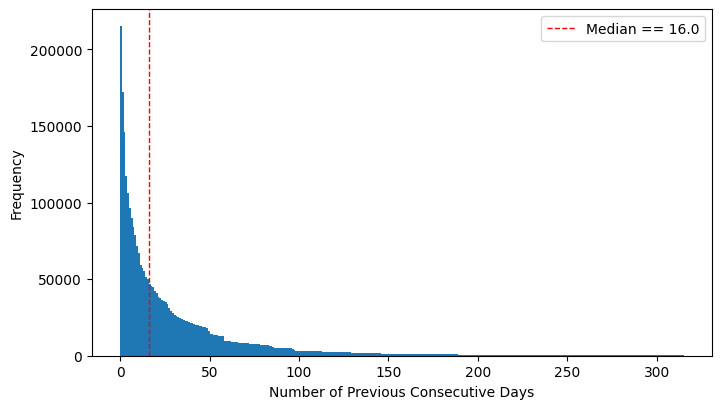

In [98]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(df.previous_days, bins=df.previous_days.max())
ax.axvline(df.previous_days.median(), color='red', linestyle='dashed', linewidth=1, label=f'Median == {df.previous_days.median()}')
ax.set_xlabel('Number of Previous Consecutive Days')
ax.set_ylabel('Frequency')
ax.legend()

Text(0, 0.5, 'Proportion of Samples Retained')

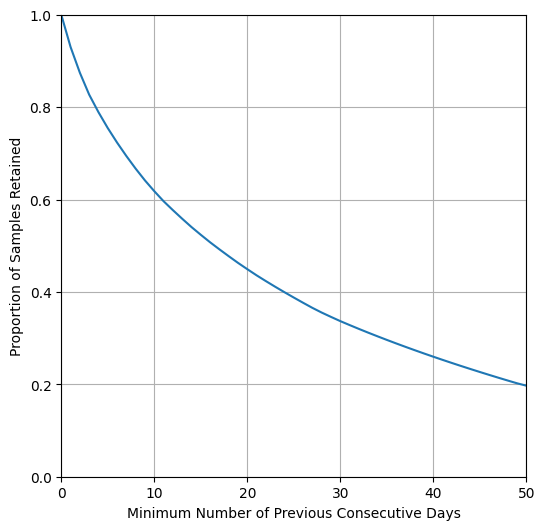

In [120]:
ratios = []
for i in range(0, 51):
    ratios.append(len(df[df.previous_days >= i]) / len(df))

plt.figure(figsize=(6, 6))
plt.plot(range(0, 51), ratios)
plt.grid()
plt.ylim(0, 1)
plt.xlim(0, 50)
plt.xlabel('Minimum Number of Previous Consecutive Days')
plt.ylabel('Proportion of Samples Retained')

In [107]:
df['filepath'] = df['country'] + '\\' + df['installation_ID'] + '\\' + df['datestring'] + '.csv'
df.to_csv(r"sample_selection.csv", index=False)